In [1]:
import sys
sys.path.append("../ingestion/python/src")
sys.path.append("../ingestion/python/enrichment_agent")

from utils import *
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

from silver_enrichment import *
from graph_silver_enrichment import *
from APIendpoint import PlacesAPI
from database import Database

import os
from dotenv import load_dotenv
load_dotenv(override=True)

llm = LLM()
places_api = PlacesAPI(os.getenv('MAPS_APP_KEY'))
db = Database()

c:\APPS\Python312\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


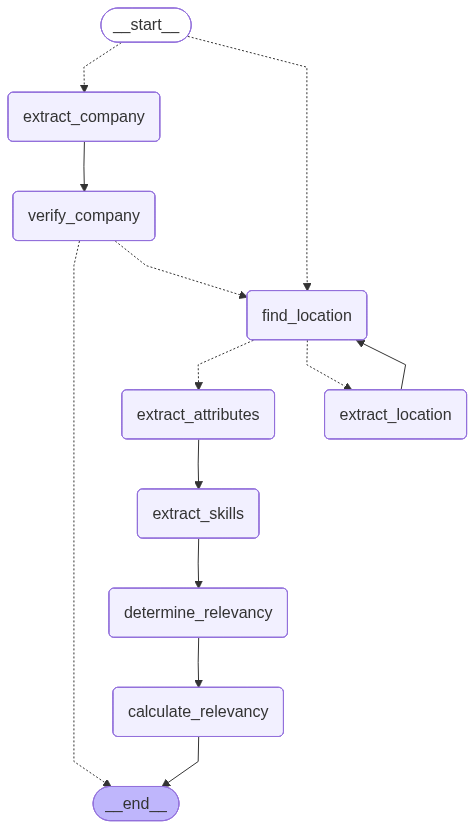

In [2]:

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [3]:
# raw = db.execute("SELECT * FROM raw.job_offer WHERE company = '' LIMIT 1;")
query = ("SELECT DISTINCT ON (id_job) * "
        "FROM raw.job_offer "
        "ORDER BY id_job "
        "LIMIT 3;")

query_prompt = ("SELECT id_prompt, prompt "
        "FROM analytics.prompt_relevancy "
        "LIMIT 1;")


raw = db.execute(query)
prompt = db.execute(query_prompt)
states = []
for row in raw:
    states.append(map_bronze_to_JobOfferState(row) | map_prompt_to_JobOfferState(prompt[0]))

In [4]:
states[0]

{'id_job': '-4L3aQ4OSv6BXj_NAAAAAA==',
 'id_company': None,
 'id_location': None,
 'api_source': 'jsearch',
 'job_title': 'Ingeniero de Datos Senior GCP',
 'offer_description': 'Axity es una compañía con más de 35 años de trayectoria que ofrece un portafolio de servicios líder en la industria: Estrategia Digital, Desarrollo de Software, Business Intelligence, Big Data, Analítica Avanzada, Seguridad e IoT.\n\nResponsabilidades\n• Diseñar, desarrollar y desplegar pipelines de datos batch y streaming en Google Cloud Platform (GCP).\n• Administrar e integrar grandes volúmenes de datos en BigQuery, garantizando calidad, modelado eficiente y optimización de costos y rendimiento.\n• Construir y administrar DAGs en Apache Airflow (Cloud Composer) para la orquestación de procesos de datos y automatización de flujos de trabajo.\n• Implementar soluciones utilizando Dataflow (Apache Beam), Dataproc (Spark y Hadoop), Cloud Workflows, Cloud Storage y Cloud Functions.\n• Monitorear, optimizar y soluc

In [5]:
columns = ("id_offer", "raw_result")

In [4]:


results = []
for state in states:
    r = graph.invoke(state)
    row = (r.get('id_job'), r)
    results.append(row)

Loading formatted geocoded file...


In [10]:
db.bulk_insert(table="staging.enriched_offers", columns=columns, data=results)

Query : INSERT INTO "staging"."enriched_offers" ("id_offer", "raw_result") VALUES ($1, $2) ;


In [6]:
import json
import datetime

# Fusion directe de la liste de tuples en un dictionnaire unique
dico_unique = dict(results)

nom_fichier = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
write_json('./test_graph', nom_fichier, dico_unique)
results

[('-4L3aQ4OSv6BXj_NAAAAAA==',
  {'id_job': '-4L3aQ4OSv6BXj_NAAAAAA==',
   'id_company': None,
   'id_location': None,
   'api_source': 'jsearch',
   'job_title': 'Ingeniero de Datos Senior GCP',
   'offer_description': 'Axity es una compañía con más de 35 años de trayectoria que ofrece un portafolio de servicios líder en la industria: Estrategia Digital, Desarrollo de Software, Business Intelligence, Big Data, Analítica Avanzada, Seguridad e IoT.\n\nResponsabilidades\n• Diseñar, desarrollar y desplegar pipelines de datos batch y streaming en Google Cloud Platform (GCP).\n• Administrar e integrar grandes volúmenes de datos en BigQuery, garantizando calidad, modelado eficiente y optimización de costos y rendimiento.\n• Construir y administrar DAGs en Apache Airflow (Cloud Composer) para la orquestación de procesos de datos y automatización de flujos de trabajo.\n• Implementar soluciones utilizando Dataflow (Apache Beam), Dataproc (Spark y Hadoop), Cloud Workflows, Cloud Storage y Cloud F

In [16]:
columns = ("id_offer", "raw_result")
query = """
    SELECT DISTINCT ON (id_job) *
    FROM raw.job_offer
    ORDER BY id_job
    LIMIT 5;
"""
raw = db.execute(query)
raw

[{'id_job': '-4L3aQ4OSv6BXj_NAAAAAA==',
  'api_source': 'jsearch',
  'job_title': 'Ingeniero de Datos Senior GCP',
  'contract_type': 'FULLTIME',
  'job_publisher': 'BeBee',
  'company': 'Axity',
  'company_website': 'https://axity.com',
  'location_raw': 'Región Metropolitana     •  a través de BeBee',
  'city': None,
  'country': None,
  'latitude': None,
  'longitude': None,
  'is_remote': False,
  'offer_url': 'https://bebee.com/cl/jobs/ingeniero-de-datos-senior-gcp-axity--talent-622414446167335822',
  'is_direct': False,
  'source_platform': 'BeBee',
  'offer_description': 'Axity es una compañía con más de 35 años de trayectoria que ofrece un portafolio de servicios líder en la industria: Estrategia Digital, Desarrollo de Software, Business Intelligence, Big Data, Analítica Avanzada, Seguridad e IoT.\n\nResponsabilidades\n• Diseñar, desarrollar y desplegar pipelines de datos batch y streaming en Google Cloud Platform (GCP).\n• Administrar e integrar grandes volúmenes de datos en B

In [17]:
len(raw)

5

In [7]:
print("attributes" in states[0])

False


In [6]:
result = places_api.search_place(company="Blend360", location="Santiago, Chile")
print(result)

result2 = places_api.search_place(company="Blend360 Chile", location="")
print(result2)

None
None
